# Section 1: DataSet
The dataset I chose contains information and demographics of all active City of Chicago employees this year. It was upadted a few days ago and is complete with full names, departments, positions, employment status (part-time or full-time), annual salaries and/or hourly rate. There's always news about corruption amongst Chicago government employees, officials and such so I grew curious about finding out of whether it was true or not. I chose this list since I was curious about whether there was a great income disparity among employees (corruption amongst employees) and if different departments had a better/worse pay rate.  I found this dataset on through a government website, City of Chicago Data Portal on the project instructions page. 

In [29]:
import pandas as pd 
df = pd.read_csv("Current_Employee_Names__Salaries__and_Position_Titles_20240424.csv")
df

,Name,Job Titles,Department,Full or Part-Time,Salary or Hourly,Typical Hours,Annual Salary,Hourly Rate
0,"GARCIA, CHRISTOPHER A",CLERK - BD OF ELECTIONS,BOARD OF ELECTION COMMISSIONERS,F,SALARY,NaN,34176.00,NaN
1,"HARRISON, LETECHIA",SR PROCUREMENT SPECIALIST,DEPARTMENT OF PROCUREMENT SERVICES,F,SALARY,NaN,90660.00,NaN
2,"GONZALEZ, MICHAEL A",POOL MOTOR TRUCK DRIVER,DEPARTMENT OF STREETS AND SANITATION,F,HOURLY,40.0,NaN,45.98
3,"RAMIREZ, RODOLFO",SANITATION LABORER,DEPARTMENT OF STREETS AND SANITATION,F,HOURLY,40.0,NaN,40.76
4,"ASHFORD, MARQUISHA D",INQUIRY AIDE III,OFFICE OF PUBLIC SAFETY ADMINISTRATION,F,SALARY,NaN,46056.00,NaN
...,...,...,...,...,...,...,...,...
31457,"CALDERON, BRANDON J",FRM OF MACHINISTS - AUTOMOTIVE,DEPARTMENT OF FLEET AND FACILITY MANAGEMENT,F,HOURLY,40.0,NaN,59.74
31458,"AMBROSE, KEVIN J",FIREFIGHTER-EMT,CHICAGO FIRE DEPARTMENT,F,SALARY,NaN,102372.00,NaN
31459,"GRADILLA, IVON",SUPERVISING TRAFFIC CONTROL AIDE,OFFICE OF EMERGENCY MANAGEMENT AND COMMUNICATIONS,F,SALARY,NaN,74844.00,NaN
31460,"SMITH, DORIS J",FOSTER GRANDPARENT,DEPARTMENT OF FAMILY AND SUPPORT SERVICES,P,HOURLY,20.0,NaN,4.00


# Section 2: Exploratory Analysis
Finding the means and medians amongst departments would be helpful on figuring if the salary data between employees in a ceratin departmen is skewed or not. We can then see if there's a outliers within the department that would create a mean that's greater than the median. I randomly chose three departments and decided to look at their descriptive statistics. I'll be looking at these departments: Board of Election Commissioners, Department of Streets and Sanitation, and Office of Public Safety Administration.

In [30]:
# I made a new dataframe containing only Board of Election Commisioners employees and found the mean of their 
# annual salaries.
df_bec = df[df["Department"] == "BOARD OF ELECTION COMMISSIONERS"]
bec_mean = df_bec["Annual Salary"].mean()
bec_mean 

63158.19085714286

In [31]:
# Then, I found the median. 
bec_median = df_bec["Annual Salary"].median()
bec_median

54624.0

We can infer that The Board of Election Commisioners data seems to be right skewed due to its mean being greater than its median by a great difference of $10,000.

In [32]:
# I made a new dataframe containing only Department of Streets and Sanitation employees and found the mean of their 
# annual salaries.
df_dss = df[df["Department"] == "DEPARTMENT OF STREETS AND SANITATION"]
dss_mean = df_dss["Annual Salary"].mean()
dss_mean 

101358.28938906752

In [33]:
# Then, I found the median. 
dss_median = df_dss["Annual Salary"].median()
dss_median

100488.0

The Department of Streets and Sanitation also seems slightly right skewed but not as much as the Board of Election Commisioners data as the difference is not as great.

In [34]:
# I made a new dataframe containing only Office of Public Safety Administration employees and found the mean of their 
# annual salaries.
df_opsa = df[df["Department"] == "OFFICE OF PUBLIC SAFETY ADMINISTRATION"]
opsa_mean = df_opsa["Annual Salary"].mean()
opsa_mean 

101732.9952838428

In [35]:
# Then, I found the median. 
opsa_median = df_opsa["Annual Salary"].median()
opsa_median

94992.0

The Office of Public Safety Adminstration data also seems to be right skewed with the mean greater than the median with difference of $5,000.

# Section 3: Exploratory Data Visualization
I'll be creating a display of histograms showing the salaries of the employees of each department mentioned above.

<Axes: >

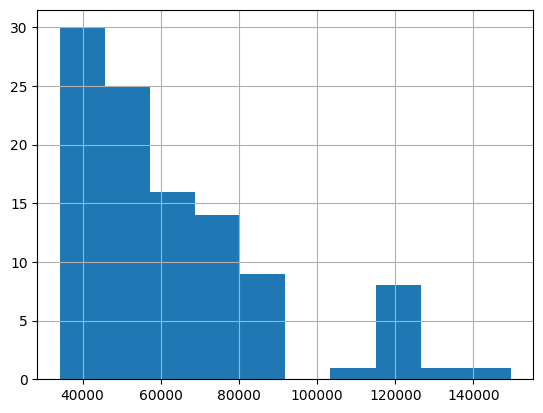

In [36]:
# On the x-axis is the annual salary, the y-axis is the frequency/number of employess that have that salary.
# This is for the Board of Election Commissioners employees.
df_bec["Annual Salary"].hist()

The Board of Election Commissioners is heavily right-skewed and seems to have a few outliers in the $100,000-140,000 range.

<Axes: >

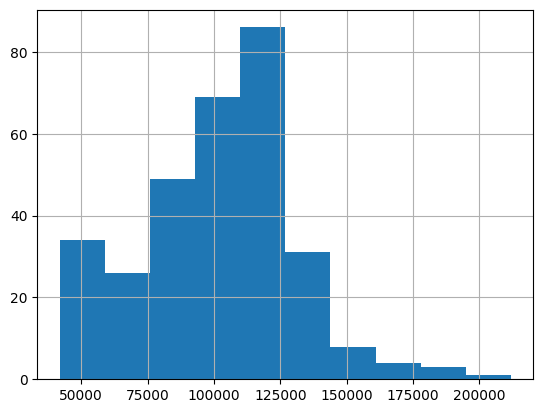

In [37]:
# This is for the Department of Streets and Sanitation employees.
df_dss["Annual Salary"].hist()

The Department of Streets and Sanitation seems to be the most normal out of the three histograms, but still slightly right skewed with not enough of data on the right side of the curve to be full normal.

<Axes: >

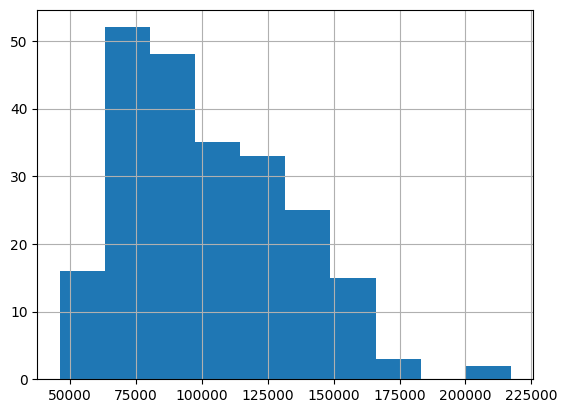

In [38]:
# This is for the Office of Public Safety Administration employees.
df_opsa["Annual Salary"].hist()

The Office of Public Safety Adminstration is heavily right skewed as shown on the histogram which confirms our inference from the mean and median we found on the previous section. Most of the employees' salaries are below $150,000 making the histogram heavily right skewed and we can also see an outlier(s) with a few on the $200,000-$225,000.

# Section 4: Data Science
A question I had was is there a salary difference between departments? We usually assume that everyone would be paid the same, but sometimes there are salary disparities.To do this, I would do hypothesis testing on each department's dataset and see if I reject or fail to reject my hypotheses. We will also use a significance level of 0.05.

*Hypotheses on Board of Election Commissioners and Department of Streets and Sanitation*

Ho: avg salary difference between both departments = 0

Ha: avg salary difference between both departments =/= 0

In [40]:
#Import ztest, z-scores in front, p-value in back
from statsmodels.stats.weightstats import ztest
bd_z_p = ztest(df_bec["Annual Salary"].dropna(), df_dss["Annual Salary"].dropna(), value = 0, alternative = 'two-sided')
bd_z_p

(-11.940402746099197, 7.286949451295315e-33)

From our calculated p-value, we can conclude that we reject the null hypothesis and that there is evidence that the average salary difference between the Board of Election Commissioners and the Department of Streets and Sanitation is not equal to 0.

*Hypotheses on Department of Streets Sanitation and Office of Public Safety Administration*

Ho: avg salary difference between both departments = 0

Ha: avg salary difference between both departments =/= 0

In [41]:
do_z_p = ztest(df_dss["Annual Salary"].dropna(), df_opsa["Annual Salary"].dropna(), value = 0, alternative = 'two-sided')
do_z_p

(-0.14195780826643778, 0.8871133322224548)

From our p-value, we can conclude that we fail to reject the null hypothesis and that there is evidence that the average salary difference between the Department of Streets and Sanitation and Office of Public Safety Adminstration is equal to 0.

*Hypotheses on Office of Public Safety Administration and Board of Election Commissioners* 

Ho: avg salary difference between both departments = 0

Ha: avg salary difference between both departments =/= 0

In [42]:
ob_z_p = ztest(df_opsa["Annual Salary"].dropna(), df_bec["Annual Salary"].dropna(), value = 0, alternative = 'two-sided')
ob_z_p

(10.906197509151749, 1.0766619257508205e-27)

From our p-value, we can conclude that we reject the null hypothesis and that there is evidence that the average salary difference between the Office of Public Safety and the Board of Election Commissioners is not equal to 0.

# Section 5: Overall Summary

In this project, I chose a dataset containing the demographics of all active City of Chicago employees. The main question I was trying to answer was is there corruption within the departments of the City of Chicago employees? Were there drastic salary disparities amongst them? I randomly chose 3 departments to do analysis on: the Board of Election Commissioners, Department of Streets and Sanitation, and the Office of Public Safety Adminstration. Through histogram visualizations, means and medians calculations, I discovered that the data for all of them were right skewed, varying from levels of skewedness. All of their means were greater than the median which backs up the right skewedness. 

After that I also did some hypothesis testing on whether if there were salary differences between the departments I chose. There was evidence of a salary difference between the Board of Election Commissioners and the Department of Streets and Sanitation and also between the Office of Public Safety and the Board of Election Commissioners. Howver in one comparison between the Department of Streets and Sanitation and Office of Public Safety Adminstration, there was evidence that there was no salary difference. Overall, I found out that there are salary disparities between departments of City of Chicago employees, which makes me wonder if there may be a confounding variable that affects our numbers. I wonder if they simply just value some departments more and so they will be compensated them more, but shouldn't all of them have the same pay rate? Using data science, we could answer that in a continuation of this project. 